In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# 1. Cargar los datos (Asumiendo que descargaste 'train.csv' de Kaggle)
df = pd.read_csv('train.csv')

In [3]:
# 1. Cargar los datos (Asumiendo que descargaste 'train.csv' de Kaggle)
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# 2. Selección de características y limpieza básica
# Las SVM solo procesan números, por lo que convertimos 'Sex' a binario (0 y 1)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [5]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S


In [6]:
#ver si hay valores nulos en el dataset
df.info()  #891 casos o filas

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    int64  
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(6), str(4)
memory usage: 83.7 KB


In [9]:
df.query("Age.isnull()")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [ ]:
# Rellenamos los valores faltantes de la edad con la mediana
df['Age'] = df['Age'].fillna(df['Age'].median())


In [10]:
df.query("Fare.isnull()") #no hay nulos en Fare

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [11]:
df.query("Cabin.isnull()") #no hay nulos en Fare

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",0,28.0,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",0,2.0,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",0,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",1,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,28.0,1,2,W./C. 6607,23.4500,NaN,S


In [13]:
df.Cabin.value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [14]:
df['Deck'] = df['Cabin'].str[0].fillna('U')

In [16]:
# Elegimos las columnas numéricas predictoras más relevantes
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features]
y = df['Survived']  # Nuestra variable objetivo (0 = No sobrevivió, 1 = Sobrevivió)


In [17]:
X

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,0,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,3,1,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,3,0,35.0,0,0,8.0500
...,...,...,...,...,...,...
886,2,0,27.0,0,0,13.0000
887,1,1,19.0,0,0,30.0000
888,3,1,28.0,1,2,23.4500
889,1,0,26.0,0,0,30.0000


In [18]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [19]:
# 3. Dividir el dataset en entrenamiento y prueba (Validación local)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
#X_train  #712
X_test    #179

,Pclass,Sex,Age,SibSp,Parch,Fare
709,3,0,28.0,1,1,15.2458
439,2,0,31.0,0,0,10.5000
840,3,0,20.0,0,0,7.9250
720,2,1,6.0,0,1,33.0000
39,3,1,14.0,1,0,11.2417
...,...,...,...,...,...,...
433,3,0,17.0,0,0,7.1250
773,3,0,28.0,0,0,7.2250
25,3,1,38.0,1,5,31.3875
84,2,1,17.0,0,0,10.5000


In [22]:
# 4. ESCALADO DE CARACTERÍSTICAS (¡Crucial para SVM!)
# Las SVM calculan distancias geométricas. Si 'Fare' va de 0 a 500 y 'Sex' es 0 o 1, 
# 'Fare' dominará por completo el modelo de forma injusta.
scaler = StandardScaler()   #transforma tus columnas numéricas para que todas 
                            #tengan una media de 0 y una desviación estándar de 1
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# 5. Crear y entrenar el modelo SVM
# Usamos el kernel 'rbf' (por defecto) para manejar relaciones no lineales
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [24]:
# 6. Evaluar las predicciones
y_pred = svm_model.predict(X_test_scaled)

In [25]:
print(f"Precisión General (Accuracy): {accuracy_score(y_test, y_pred):.4f}\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))


Precisión General (Accuracy): 0.8101

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



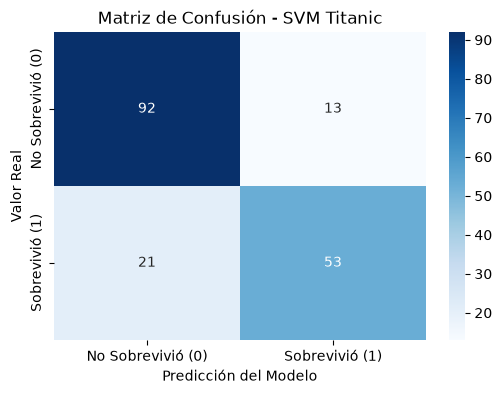

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calcular la matriz real con tus variables
cm = confusion_matrix(y_test, y_pred)

# Graficar un mapa de calor moderno
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Sobrevivió (0)', 'Sobrevivió (1)'], 
            yticklabels=['No Sobrevivió (0)', 'Sobrevivió (1)'])

plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - SVM Titanic')
plt.show()


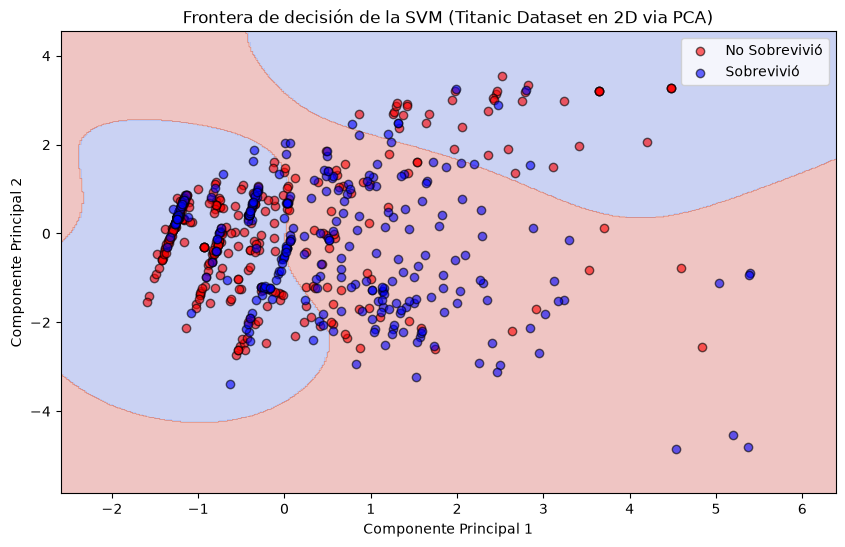

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# 1. Reducir las características escaladas a solo 2 dimensiones usando PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled) # Viene del paso anterior

# 2. Entrenar la SVM en este nuevo espacio bidimensional
svm_2d = SVC(kernel='rbf', C=1.0)
svm_2d.fit(X_train_pca, y_train)

# 3. Crear una malla (meshgrid) para pintar las regiones de decisión
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predicciones en la malla para dibujar el fondo de color
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Dibujar el mapa de contorno y los pasajeros reales
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Separar sobrevivientes de los que no para darles color propio
plt.scatter(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1], c='red', label='No Sobrevivió', alpha=0.6, edgecolors='k')
plt.scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1], c='blue', label='Sobrevivió', alpha=0.6, edgecolors='k')

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Frontera de decisión de la SVM (Titanic Dataset en 2D via PCA)')
plt.legend()
plt.show()


In [30]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import contingency_matrix

# 1. Cargamos y limpiamos los datos (igual que con la SVM)
df = pd.read_csv('train.csv')
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features]
y_real = df['Survived']  # Guardamos la respuesta real solo para comparar al final

# 2. Escalamos los datos (K-Means se basa en distancias, ¡es obligatorio escalar!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicamos K-Means pidiéndole exactamente 2 grupos (K=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. Comparamos los Clústeres creados con la Supervivencia Real
print("Matriz de Contingencia (Cruces de datos):")
print(pd.crosstab(df['Survived'], df['Cluster'], rownames=['Real (Survived)'], colnames=['Clúster Asignado']))


Matriz de Contingencia (Cruces de datos):
Clúster Asignado    0    1
Real (Survived)           
0                 450   99
1                 191  151


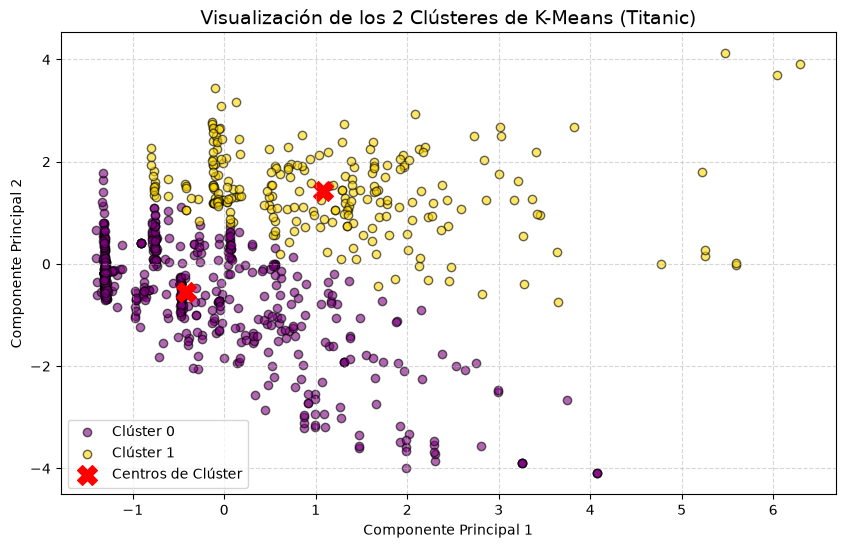

In [31]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Reducir las características escaladas a 2 dimensiones para poder graficar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Configurar el gráfico
plt.figure(figsize=(10, 6))

# Dibujar los puntos del Clúster 0
plt.scatter(X_pca[df['Cluster'] == 0, 0], X_pca[df['Cluster'] == 0, 1], 
            c='purple', label='Clúster 0', alpha=0.6, edgecolors='k')

# Dibujar los puntos del Clúster 1
plt.scatter(X_pca[df['Cluster'] == 1, 0], X_pca[df['Cluster'] == 1, 1], 
            c='gold', label='Clúster 1', alpha=0.6, edgecolors='k')

# 3. Graficar los centros de cada clúster (Centroides)
# Primero transformamos los centros al espacio PCA
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
            c='red', marker='X', s=200, label='Centros de Clúster')

# 4. Detalles estéticos
plt.title('Visualización de los 2 Clústeres de K-Means (Titanic)', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Mostrar el gráfico en pantalla
plt.show()


In [32]:
# Crear un DataFrame para ver qué columnas reales componen cada PCA
pesos_pca = pd.DataFrame(
    pca.components_, 
    columns=features, 
    index=['Componente Principal 1 (Eje X)', 'Componente Principal 2 (Eje Y)']
)

print("Pesos de las variables originales en cada componente:")
print(pesos_pca.round(3).T)


Pesos de las variables originales en cada componente:
        Componente Principal 1 (Eje X)  Componente Principal 2 (Eje Y)
Pclass                          -0.408                          -0.536
Sex                              0.395                          -0.096
Age                             -0.006                           0.557
SibSp                            0.371                          -0.432
Parch                            0.462                          -0.367
Fare                             0.571                           0.267
